# 02 — Feature Engineering
Build and save feature matrices for train and test.

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engineering import build_features, FEATURE_COLS
sns.set_style('whitegrid')


In [2]:
train = build_features('train')
test  = build_features('test')
print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print()
print("Feature columns:", FEATURE_COLS)


Train: (10000, 17)
Test:  (10000, 15)

Feature columns: ['tenure_days', 'total_visits', 'wellco_visits', 'health_content_ratio', 'days_since_wellco', 'unique_wellco_domains', 'app_sessions', 'days_since_app', 'app_sessions_last7d', 'icd_E11_9', 'icd_I10', 'icd_Z71_3', 'unexpected_icd_count', 'expected_icd_count']


In [3]:
print("Train features — summary:")
print(train[FEATURE_COLS].describe().T[['mean','std','min','max']].round(3))


Train features — summary:
                          mean      std   min      max
tenure_days            303.605  149.313  45.0  561.000
total_visits            25.934   17.237   0.0  140.000
wellco_visits           10.150    7.766   0.0   62.000
health_content_ratio     0.367    0.147   0.0    0.875
days_since_wellco        3.556   14.227   0.0   99.000
unique_wellco_domains    3.250    1.029   0.0    4.000
app_sessions             9.779    3.628   0.0   26.000
days_since_app           1.068    2.025   0.0   99.000
app_sessions_last7d      4.896    2.406   0.0   17.000
icd_E11_9                0.588    0.492   0.0    1.000
icd_I10                  0.589    0.492   0.0    1.000
icd_Z71_3                0.590    0.492   0.0    1.000
unexpected_icd_count     2.887    1.336   0.0    7.000
expected_icd_count       1.766    0.868   0.0    3.000


In [4]:
print("Test features — summary:")
print(test[FEATURE_COLS].describe().T[['mean','std','min','max']].round(3))


Test features — summary:
                          mean      std   min      max
tenure_days            303.740  148.373  45.0  561.000
total_visits            26.173   17.220   0.0  156.000
wellco_visits           10.219    7.799   0.0   66.000
health_content_ratio     0.365    0.146   0.0    0.875
days_since_wellco        3.662   14.550   0.0   99.000
unique_wellco_domains    3.259    1.030   0.0    4.000
app_sessions             9.796    3.668   0.0   25.000
days_since_app           1.076    2.044   0.0   99.000
app_sessions_last7d      4.898    2.419   0.0   21.000
icd_E11_9                0.591    0.492   0.0    1.000
icd_I10                  0.600    0.490   0.0    1.000
icd_Z71_3                0.592    0.491   0.0    1.000
unexpected_icd_count     2.881    1.325   0.0    7.000
expected_icd_count       1.783    0.870   0.0    3.000


In [5]:
# Covariate shift: train vs test
rows = []
for col in FEATURE_COLS:
    tr = train[col]
    te = test[col]
    smd = (te.mean() - tr.mean()) / np.sqrt((tr.std()**2 + te.std()**2)/2 + 1e-9)
    rows.append({'feature': col, 'train_mean': tr.mean(), 'test_mean': te.mean(), 'SMD': smd})
shift_df = pd.DataFrame(rows).sort_values('SMD', key=abs, ascending=False)
print("Covariate shift (test vs train):")
print(shift_df.to_string(index=False))


Covariate shift (test vs train):
              feature  train_mean  test_mean       SMD
              icd_I10    0.588700   0.599600  0.022197
   expected_icd_count    1.766300   1.783100  0.019330
         total_visits   25.934000  26.172900  0.013867
 health_content_ratio    0.366773   0.365248 -0.010426
        wellco_visits   10.150000  10.218700  0.008827
unique_wellco_domains    3.250200   3.258800  0.008355
    days_since_wellco    3.556400   3.661900  0.007332
            icd_E11_9    0.588000   0.591100  0.006302
            icd_Z71_3    0.589600   0.592400  0.005695
         app_sessions    9.778900   9.796100  0.004715
 unexpected_icd_count    2.886700   2.881100 -0.004209
       days_since_app    1.068100   1.076000  0.003883
  app_sessions_last7d    4.895800   4.898000  0.000912
          tenure_days  303.604700 303.739800  0.000908


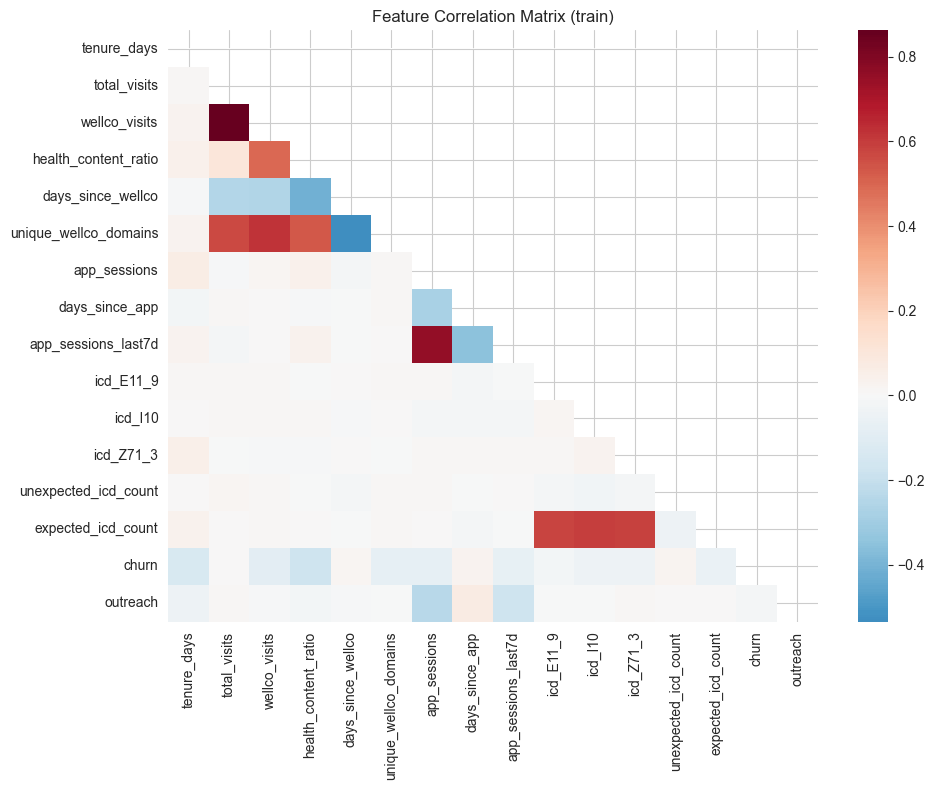

In [6]:
# Correlation heatmap on train
fig, ax = plt.subplots(figsize=(10, 8))
corr = train[FEATURE_COLS + ['churn', 'outreach']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix (train)', fontsize=12)
plt.tight_layout()
plt.savefig('features_correlation.png', bbox_inches='tight')
plt.show()


In [7]:
# Save to parquet
train.to_parquet('train_features.parquet', index=False)
test.to_parquet('test_features.parquet', index=False)
print("Saved train_features.parquet and test_features.parquet")


Saved train_features.parquet and test_features.parquet
